### Imports

In [5]:
"""Imports."""
import numpy as np
import matplotlib.pyplot as plt
from color_utils import srgb_to_oklab, oklab_to_srgb
from file_utils import get_image
from image_utils import l_flatten, print_image, print_oklab_l, get_color_positions
# from PIL import Image

%load_ext autoreload
%autoreload 2

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


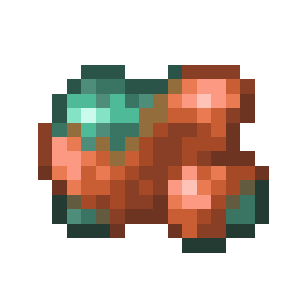

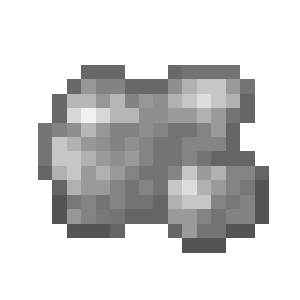

In [22]:
# get image from file
# img = get_image("asve", "apple.png")
# img = get_image("caverns_and_chasms", "music_disc_copy.png")
img = get_image("vanilla", "raw_copper.png")
# img = get_image("scratch", "snake_test.png")
# img = get_image("create", "blaze_cake.png")
# img = get_image("reimagined", "golden_apple.png")

# PIL Image has functions that handle resizing,
# rotation, and cropping, as well as a 256-palette getter.

# srgb array
img_arr = np.asarray(img)
print_image(img)

# oklab array
oklab_arr = srgb_to_oklab(img_arr)
print_oklab_l(oklab_arr)

# L array
lum_arr = l_flatten(oklab_arr)

In [ ]:
from collections import defaultdict

# Get unordered color index
color_dict = get_color_positions(oklab_arr)
unique_colors = list(color_dict.keys())

# Get data
adjacency_counts = defaultdict(int)
lateral_neighbors = [
            (-1,0),
    (0,-1),         (0,1),
            (1,0)
]
diagonal_neighbors = [
    (-1,-1), (-1,1),
    (1,-1), (1,1)
]
for current_color in unique_colors:
    for (y, x) in color_dict[current_color]:
        for dy, dx in lateral_neighbors:
            ny = y + dy
            nx = x + dx
            maxy = oklab_arr.shape[0]
            maxx = oklab_arr.shape[1]
            if ny<0 or nx<0 or ny >= maxy or nx >= maxx:
                continue

            neighbor = tuple(oklab_arr[ny, nx])
            #if neighbor == current_color:
            #    continue
            if len(neighbor) == 4 and neighbor[3] == 0:
                continue

            adjacency_counts[(current_color, neighbor)] += 1

ramp_matrix = []

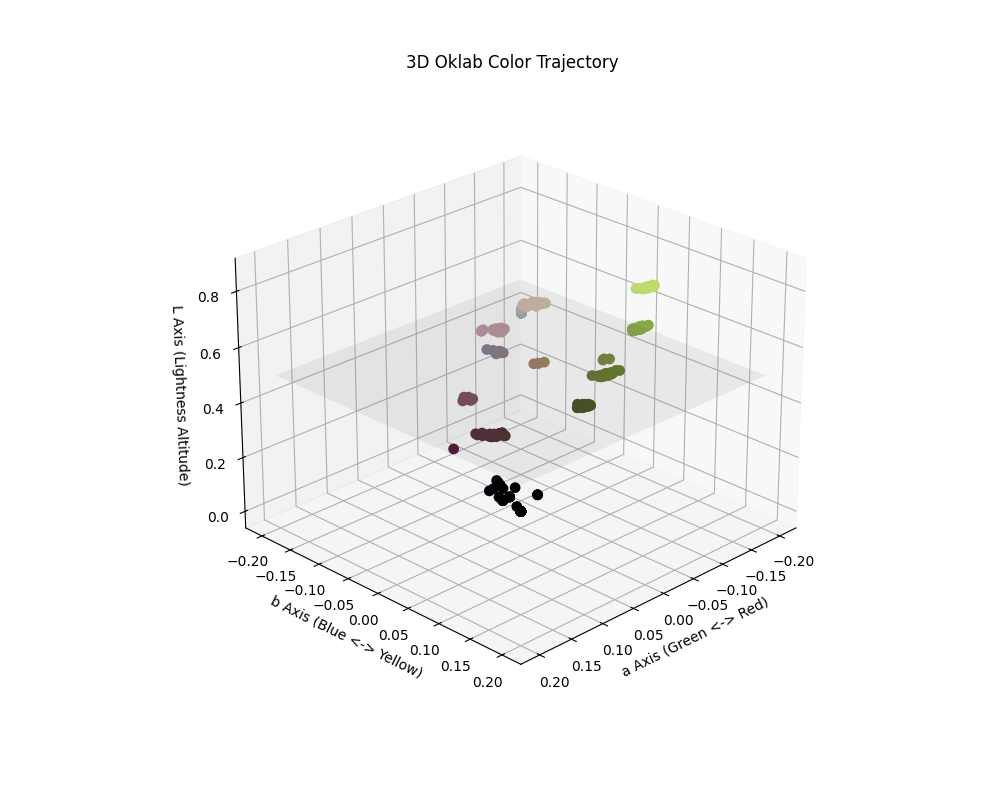

In [17]:
def graph_colors(oklab_points):
    rgb_colors = oklab_to_srgb(oklab_points) / 255
    rgb_colors = np.clip(rgb_colors, 0.0, 1.0)

    # 3. Build the 3D Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')

    # Map the coordinates: X=a, Y=b, Z=L (Lightness as altitude)
    # We pass our converted rgb_colors array directly to the 'c' argument
    sc = ax.scatter(oklab_points[:,1], oklab_points[:,2], oklab_points[:,0], c=rgb_colors, s=60, edgecolors='none', alpha=1.0)

    # 4. Formatting the structural layout
    ax.set_xlabel('a Axis (Green <-> Red)')
    ax.set_ylabel('b Axis (Blue <-> Yellow)')
    ax.set_zlabel('L Axis (Lightness Altitude)')
    ax.set_title('3D Oklab Color Trajectory', pad=20)

    # Optional: Add a subtle gray plane at L=0.5 to anchor the center "neutral" axis
    xx, yy = np.meshgrid(np.linspace(-0.2, 0.2, 2), np.linspace(-0.2, 0.2, 2))
    ax.plot_surface(xx, yy, np.full_like(xx, 0.5), color='gray', alpha=0.1, zorder=0)

    # Adjust viewing angle to easily see the hue curves and lightness height
    ax.view_init(elev=25, azim=45)
    plt.show()

%matplotlib widget

oklab_points = oklab_arr.reshape(-1, 4)[:, :-1]
graph_colors(oklab_points)

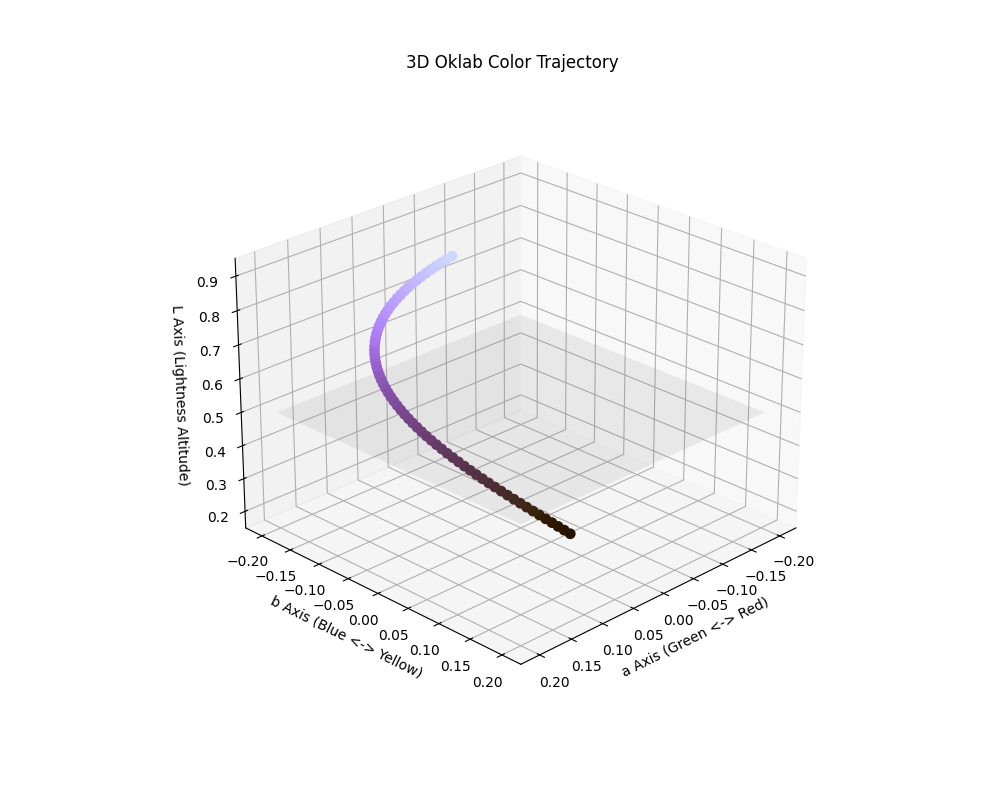

In [9]:
def test_purple_samples():
    num_points = 70
    L = np.linspace(0.2, 0.9, num_points)       # Monotonically increasing lightness
    a = np.sin(np.linspace(0, 3, num_points)) * 0.1  # Shifting red/green profile
    b = np.cos(np.linspace(1, 4, num_points)) * 0.15 # Shifting yellow/blue profile

    # Stack them into an (N, 3) array of Oklab coordinates
    return np.column_stack((L, a, b))

graph_colors(test_purple_samples())